## Практика: визуализируем данные
1. Загружаем данные, смотрим информацию

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: f'{x:.2f}')
schools = pd.read_json('../../data/schools.json')
schools.head(5)

,building_area,is_living,adress,object_name,capacity
0,1369.16,False,"ул. Курляндская, д.43, литера А",Государственное бюджетное общеобразовательное ...,450
1,891.26,False,"ул. Бумажная, д.5, литера А",Государственное бюджетное общеобразовательное ...,450
2,899.55,False,"Нарвский пр., д.4-6, литера А",Государственное бюджетное общеобразовательное ...,425
3,933.39,False,"Старо-Петергофский пр., д. 33 лит. Б",Государственное бюджетное общеобразовательное ...,50
4,989.02,True,"Курляндская улица, дом 29, литера А",Государственное бюджетное общеобразовательное ...,116


In [2]:
# Настройка стиля (можно выбрать: 'default', 'seaborn-v0_8', 'seaborn-v0_8-whitegrid', 'ggplot', 'fivethirtyeight')
plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans',
                                   'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False 

2. Гистограмма площади зданий

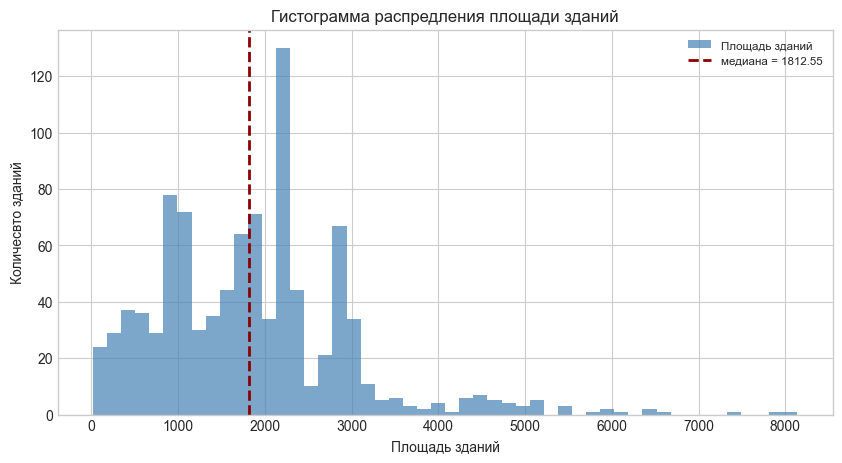

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

plt.hist(schools['building_area'], bins=50, color='steelblue', alpha=0.7, label='Площадь зданий')
median_value = schools['building_area'].median()
plt.axvline(median_value, color='darkred', linestyle='--', linewidth=2, label=f'медиана = {median_value}')
plt.xlabel('Площадь зданий')
plt.ylabel('Количесвто зданий')
plt.title('Гистограмма распредления площади зданий')
plt.legend(loc='best', fontsize= 'small') # fontsize: int or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
plt.show()

Значения атрибута *loc* для оределения местоположения легенды

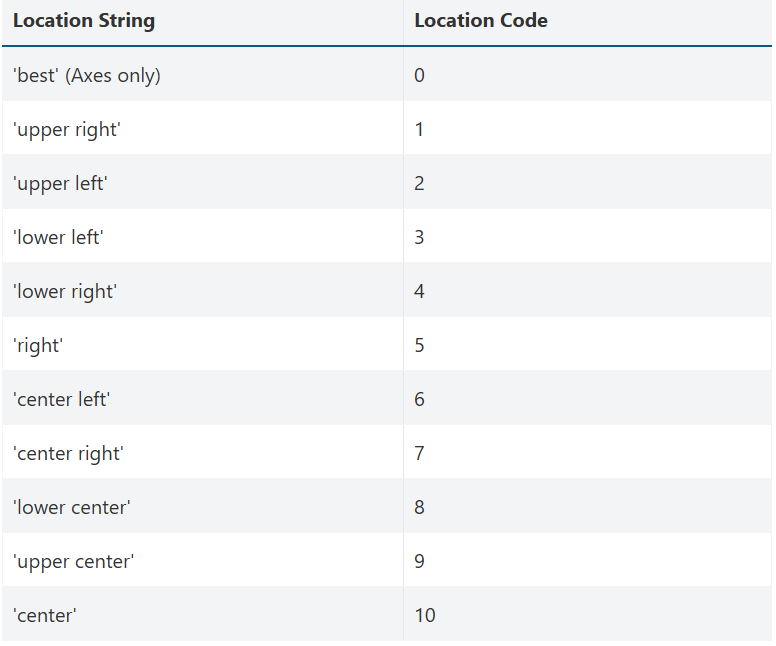

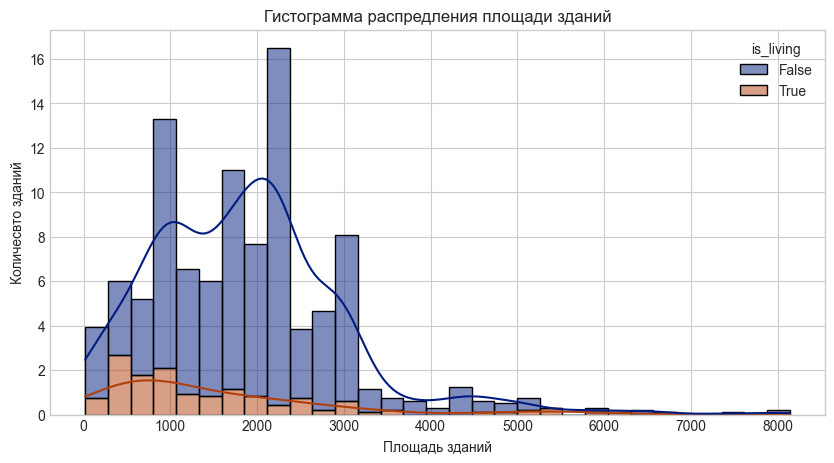

In [4]:
# то же самое но с seaborn
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
            schools, 
            x='building_area', 
            fill=True, 
            hue='is_living',
            multiple='stack', # 'layer', 'dodge', 'stack', 'fill'
            element='bars', # bars', 'step', 'poly'
            stat='percent',
            kde=True, 
            palette="dark" # deep, pastel, muted, bright, pastel, dark, colorblind
)
plt.xlabel('Площадь зданий')
plt.ylabel('Количесвто зданий')
plt.title('Гистограмма распредления площади зданий')
plt.show()

3. Круговая диаграмма: доля жилых/нежилых

In [5]:
# группируем вместимость по признаку жилой/нежилой застройки
capasity_distr = schools.groupby('is_living')['capacity'].count()
capasity_distr

is_living
False    827
True     137
Name: capacity, dtype: int64

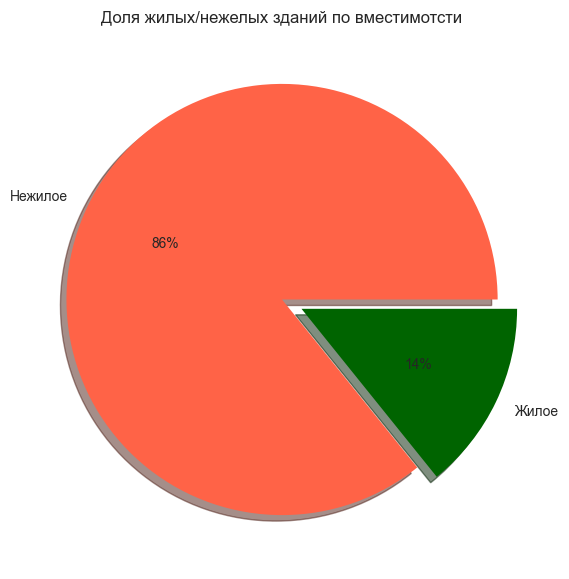

In [6]:
fig, ax = plt.subplots(figsize=(8,7))

plt.pie(capasity_distr,
        labels=['Нежилое', 'Жилое'],
        explode=(0, 0.1),
        colors=['tomato', 'darkgreen'],
        autopct=lambda x: f'{x:.0f}%',
        shadow=True
         )
plt.title("Доля жилых/нежелых зданий по вместимотсти")
plt.show()

Подробнее о цветах и цветовых схемах [здесь](https://matplotlib.org/stable/users/explain/colors/index.html).

4. Диаграмма рассеяния

In [7]:
schools.columns

Index(['building_area', 'is_living', 'adress', 'object_name', 'capacity'], dtype='object')

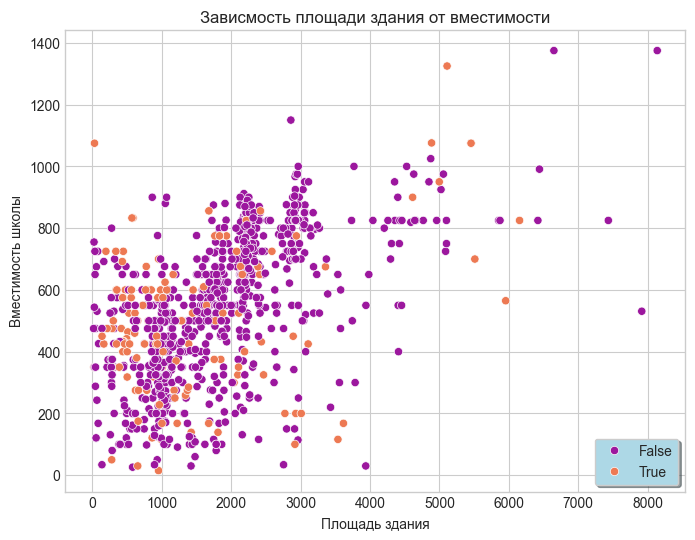

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(data=schools, 
                x ='building_area', 
                y='capacity',
                hue='is_living',
                palette='plasma'
                )
plt.xlabel('Площадь здания')
plt.ylabel('Вместимость школы')
plt.title('Зависмость площади здания от вместимости')
plt.legend(loc='lower right', fontsize='medium', frameon=True, facecolor='lightblue', shadow=True)
plt.show()

#### Тепловая карта корреляции (heatmap)

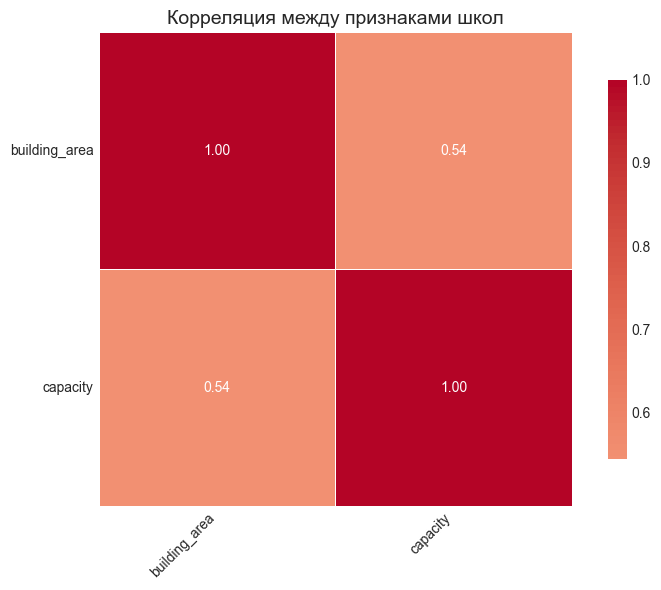

In [9]:
# 5. Тепловая карта корреляции
# Выбираем только числовые колонки
numeric_cols = schools.select_dtypes(include=['int64', 'float64'])

# Строим матрицу корреляции
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True,           # показывать числа в ячейках
            cmap='coolwarm',      # цветовая схема: красный (положит) → синий (отрицат)
            center=0,             # значение 0 — белый цвет
            fmt='.2f',            # формат чисел (2 знака после запятой)
            square=True,          # квадратные ячейки
            linewidths=0.5,       # толщина линий между ячейками
            cbar_kws={'shrink': 0.8})  # размер цветовой шкалы
plt.title('Корреляция между признаками школ', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### 6. Ящик с усами (boxplot) для сравнения распределений

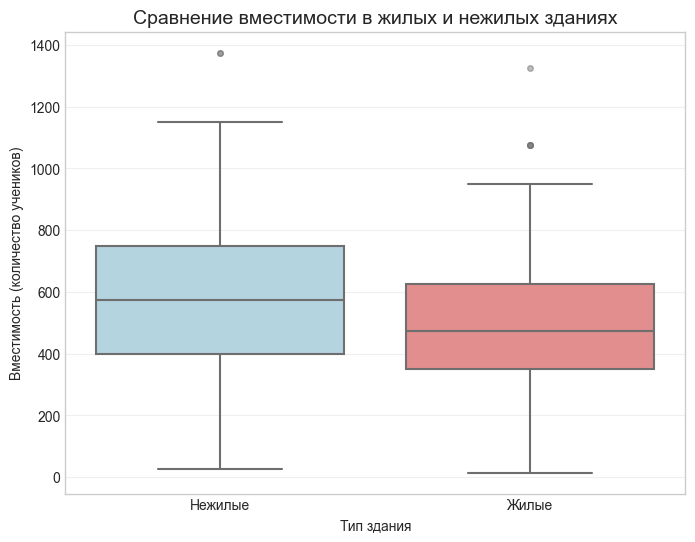

In [10]:
plt.figure(figsize=(8, 6))

# Создаём колонку с понятными подписями
schools['building_type'] = schools['is_living'].map({True: 'Жилые', False: 'Нежилые'})

sns.boxplot(data=schools, 
            x='building_type', 
            y='capacity',
            hue='building_type',      # цвет по тому же признаку
            palette=['lightblue', 'lightcoral'],
            linewidth=1.5,
            fliersize=4,              # размер точек-выбросов
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5))

plt.title('Сравнение вместимости в жилых и нежилых зданиях', fontsize=14)
plt.xlabel('Тип здания')
plt.ylabel('Вместимость (количество учеников)')
plt.grid(axis='y', alpha=0.3)
plt.show()